# 01 - Project Setup and AOI
This notebook initializes folders, defines AOI, exports AOI GeoJSON, and saves AOI visualization.

In [1]:
%pip -q install requests rasterio pyproj shapely matplotlib numpy

In [2]:
import json
import os
from pyproj import Geod
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
AOI_DIR = os.path.join(DATA_DIR, 'aoi')
LANDSAT_DIR = os.path.join(DATA_DIR, 'landsat')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs')
FIG_DIR = os.path.join(OUTPUT_DIR, 'figures')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
EXPORT_DIR = os.path.join(PROJECT_ROOT, 'exports')

for d in [DATA_DIR, AOI_DIR, LANDSAT_DIR, PROCESSED_DIR, OUTPUT_DIR, FIG_DIR, MODEL_DIR, EXPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project root:', PROJECT_ROOT)

Project root: /content/lulc_notebook_project


In [3]:
# AOI polygon (Brampton sample)
aoi_geojson = {
    'type': 'FeatureCollection',
    'features': [{
        'type': 'Feature',
        'properties': {'name': 'Brampton_AOI'},
        'geometry': {
            'type': 'Polygon',
            'coordinates': [[
                [-79.96170628057298, 43.28864843402968],
                [-79.96170628057298, 43.22522453460496],
                [-79.86976155590753, 43.22522453460496],
                [-79.86976155590753, 43.28864843402968],
                [-79.96170628057298, 43.28864843402968]
            ]]
        }
    }]
}

coords = aoi_geojson['features'][0]['geometry']['coordinates'][0]
lons = [c[0] for c in coords]
lats = [c[1] for c in coords]
BBOX = [min(lons), min(lats), max(lons), max(lats)]
CENTER_LAT = (BBOX[1] + BBOX[3]) / 2
CENTER_LON = (BBOX[0] + BBOX[2]) / 2

geod = Geod(ellps='WGS84')
poly_lons, poly_lats = zip(*coords)
area_m2, _ = geod.polygon_area_perimeter(poly_lons, poly_lats)
AOI_AREA_KM2 = abs(area_m2) / 1e6

print('BBOX:', BBOX)
print(f'Center: ({CENTER_LAT:.5f}, {CENTER_LON:.5f})')
print(f'AOI Area: {AOI_AREA_KM2:.2f} km^2')

BBOX: [-79.96170628057298, 43.22522453460496, -79.86976155590753, 43.28864843402968]
Center: (43.25694, -79.91573)
AOI Area: 52.61 km^2


In [4]:
# Export AOI GeoJSON and project config
aoi_path = os.path.join(AOI_DIR, 'aoi.geojson')
with open(aoi_path, 'w', encoding='utf-8') as f:
    json.dump(aoi_geojson, f, indent=2)

config = {
    'project_root': PROJECT_ROOT,
    'bbox': BBOX,
    'center': [CENTER_LAT, CENTER_LON],
    'aoi_area_km2': AOI_AREA_KM2,
    'paths': {
        'aoi_geojson': aoi_path,
        'landsat_dir': LANDSAT_DIR,
        'processed_dir': PROCESSED_DIR,
        'fig_dir': FIG_DIR,
        'model_dir': MODEL_DIR,
        'export_dir': EXPORT_DIR
    }
}

config_path = os.path.join(DATA_DIR, 'config.json')
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2)

print('Saved:', aoi_path)
print('Saved:', config_path)

Saved: /content/lulc_notebook_project/data/aoi/aoi.geojson
Saved: /content/lulc_notebook_project/data/config.json


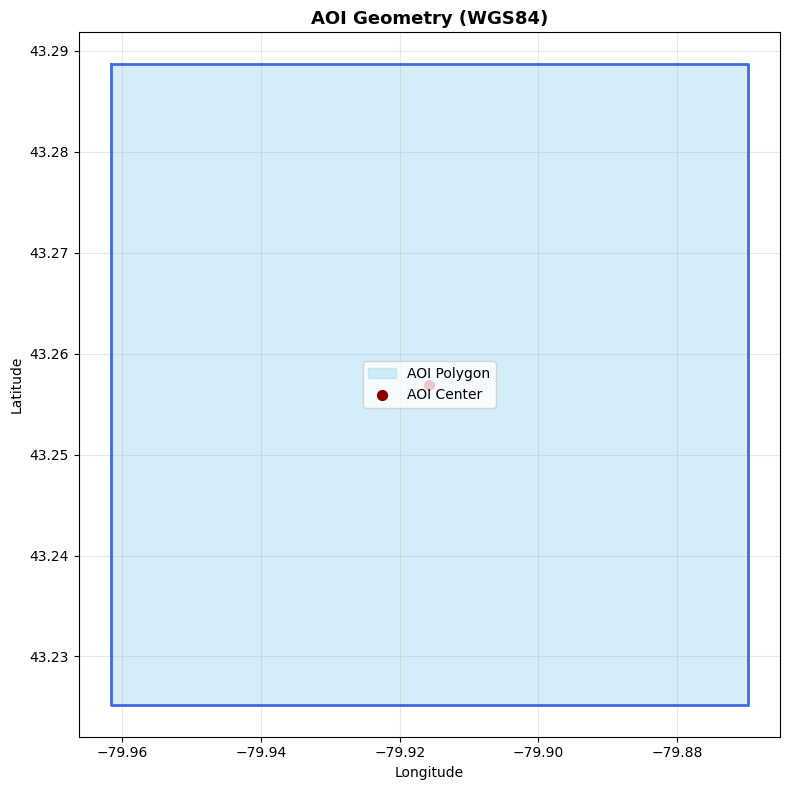

Saved: /content/lulc_notebook_project/outputs/figures/01_aoi_geometry.png


In [5]:
# AOI visualization
xs = [p[0] for p in coords]
ys = [p[1] for p in coords]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(xs, ys, color='royalblue', linewidth=2)
ax.fill(xs, ys, color='skyblue', alpha=0.35, label='AOI Polygon')
ax.scatter([CENTER_LON], [CENTER_LAT], color='darkred', s=50, label='AOI Center')
ax.set_title('AOI Geometry (WGS84)', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(alpha=0.3)
ax.legend()

out_fig = os.path.join(FIG_DIR, '01_aoi_geometry.png')
plt.tight_layout()
plt.savefig(out_fig, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', out_fig)